In [1]:
import re
import numpy as np
import scipy as scp
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.special import erf
from datetime import datetime
import h5py, math
import itertools

In [2]:
# global variables
EDM_pos = 11990.0
EDM_mm = 184.4
EDM_height = 70.0
EDM_width = 70.0
EDM_norm_rate = 354000.0
EDM_background_rate = 10000.0
EDM_delta_x = 515.25

UCN_pos = 325.0
UCN_mm = 265.5
UCN_height = 50.0
UCN_width = 100.0
UCN_norm_rate = 194.0
UCN_background_rate = 0.43
UCN_delta_x = 513.5

In [3]:
def Gauss_fit(x, A, B, y0):
    return A * np.exp(-(x)**2 / (2 * B**2)) + y0

def integrated_gauss(x, A, mu, sigma, c): # A .. aplitude, mu.. Mittelpunkt, sigma... breite, c... offset
    return c + 0.5 * A * (1 + erf((x-mu) / (np.sqrt(2) * sigma)))

In [4]:
def fill_data(data, sw_pos, mon_edm = None, mon_edm_err = None):
    results = []
    norm = 250

    for x, (neutrons, rate, err, mon, stdmon) in data:
        neutrons = np.array(neutrons)

        N = np.sum(neutrons)
        R = N / (200 * len(neutrons)) * 1000
        sigma = np.sqrt(N) / (200 * len(neutrons)) * 1000

        results.append({"x": x, "n": neutrons, "rate": rate, "err": err, "mon": mon, "merr": stdmon, "N": N, "R": R, "sigma": sigma})

    #sw_pos = [325.0, 1033.5, 2047.0, 3074.3, 4058.8, 5050.3, 6103.7, 7063.2, 8063.6, 9087.1, 10277.5, 11063.0, 11990.0, 13029.4, 14032.9, 15204.3]
    #mon_edm = [10224.77, 10331.43, 19465.48, 46082.30, 79286.42, 119170.52, 166417.27, 211048.65, 256269.98, 299004.57, 340775.60, 360316.03, 351215.85, 291115.73, 232519.42, 170402.42]
    #mon_edm_err = [13.05, 13.12, 18.01, 27.71, 36.35, 44.57, 52.67, 59.31, 65.35, 70.59, 75.36, 77.49, 76.51, 69.66, 62.25, 53.29]
    

         
    

    
    # Subplots: rate | monitor
    fig, axes = plt.subplots(len(results), 2, figsize=(10, 3 * len(results)), sharex=True)

    if len(results) == 1:
        axes = [axes]
    for ax_row, res in zip(axes, results):
        ax_mon, ax_rate = ax_row

        y = np.asarray(res["rate"]).flatten()
        yerr = np.asarray(res["err"]).flatten()
        m = np.asarray(res["mon"]).flatten()
        merr = np.asarray(res["merr"]).flatten()

        R = res["R"]
        sigma = res["sigma"]

        #y_corr = y * norm / m
        #yerr_corr = y_corr * np.sqrt((yerr / y)**2 + (merr / m)**2)

        print(res['x'], len(res['n']), np.sum(res['n']), R, sigma)
        if len(sw_pos) != len(m):
            print("Error: Missing values2")

        # plot rate
        #ax_rate.errorbar(x=range(len(y)), y=y, yerr=yerr, fmt='o', label='UCN Monitor')
        #ax_rate.errorbar(range(len(y_corr)), y_corr, yerr=yerr_corr, fmt='o', label='corrected rate', color = 'green')
        #ax_rate.axhline(R, color='red', label='mean rate')
        #ax_rate.axhline(R + sigma, linestyle='--', color='red', alpha=0.6)
        #ax_rate.axhline(R - sigma, linestyle='--', color='red', alpha=0.6)

        #ax_rate.set_title(f"x = {res['x']} (Rate)")
        #ax_rate.set_ylabel("Rate [mcps]")
        #ax_rate.grid(True)
        #ax_rate.legend()

        # plot monitor
        ax_mon.errorbar(sw_pos, m, yerr=merr, fmt='o', label='UCN Monitor', color='orange')
        ax_mon.set_title("UCN rate vs. switcher position")
        ax_mon.set_ylabel("Monitor [cps]")
        ax_mon.grid(True)
        ax_mon.legend()

        if mon_edm != None :
            if len(sw_pos) != len(mon_edm) or len(sw_pos) != len(mon_edm_err):
                print("Error: Missing values")
            
            plt.errorbar(sw_pos, mon_edm, yerr=mon_edm_err, fmt='o', capsize=3, label='EDM Monitor')
            plt.legend()
            plt.xlabel("Switcher Motor Position [A.U.]")
            plt.ylabel("rate [cps]")
            plt.title("EDM rate vs. switcher position")
            plt.grid(True)


    axes[-1][0].set_xlabel("Switcher Position [A.U.]")
    axes[-1][1].set_xlabel("Switcher Position [A.U.]")

    plt.tight_layout()
    plt.show()

    return results




In [5]:
def motorpos_to_mm(sw_pos):
    h = []

    step_mm = (EDM_mm-UCN_mm)/(EDM_pos-UCN_pos)
    for pos in sw_pos:
        h.append(UCN_mm + step_mm*(pos-UCN_pos))
    return np.array(h)

def mm_to_motorpos():
    #todo
    return 0

In [6]:
# do overlap function of areas
def calc_areaoverlap(sw_mm, center, height):
    overlap = []
    k = 1.0/height
    for pos_mm in sw_mm:
        x = 1- k*abs(center-pos_mm)
        if x < 0:
            x = 0
        overlap.append(x)
    return np.array(overlap)

In [7]:
#print(get_data((8327,8350)))
def calc_areacorr_rate(mon, std_mon, overlaps, threshold = 0.01):
    turbine_rate = np.zeros(len(overlaps))
    turbine_rate_err = np.zeros(len(overlaps))
    for i in range(len(mon)):
        if overlaps[i] > threshold:
            turbine_rate[i] = mon[i]/overlaps[i]
            turbine_rate_err[i] = std_mon[i]/overlaps[i]
    return turbine_rate, turbine_rate_err

In [8]:
#print(get_data((8327,8350)))
def calc_areacorr_rate2(mon, std_mon, overlaps, background_rate, threshold = 0.01):
    background_rate_err = math.sqrt(background_rate)
    turbine_rate = np.zeros(len(overlaps))
    turbine_rate_err = np.zeros(len(overlaps))
    for i in range(len(mon)):
        if overlaps[i] > threshold:
            turbine_rate[i] = (mon[i]-background_rate*(1-overlaps[i]))/overlaps[i]
            turbine_rate_err[i] = (std_mon[i]+background_rate_err*(1-overlaps[i]))/overlaps[i]
    return turbine_rate, turbine_rate_err

In [9]:
def get_UCN_mon(ranges, exclude = None):
    mon = []
    stdmon = []
    data = []
    std = []
    neutrons = []
    roi0, roi1 = 90,900
    roi2, roi3 = 40, 400
    exclude = set(exclude) if exclude is not None else set()
    if isinstance(ranges, tuple):
        ranges = [ranges]
    for i0, i1 in ranges:
        for i in range(i0, i1+1):
            if i in exclude:
                continue
            path = '/home/fiscfeli/MyData/byProposal/exp_3-14-458_262_pf2ucn/rawdata/00' + str(i) + '.nxs'
            try:
                file = h5py.File(path, 'r')
                cycletime = np.array(file['/entry0/time'][:])
                numor = np.array(file['/entry0/run_number'])
                if cycletime < 250:
                    arr1 = np.array(file['/entry0/PF2UCN/Detector1/data'][:])[roi2:roi3,0,0:60]
                    arr2 = np.array(file['/entry0/PF2UCN/Detector2/data'][:])[roi0:roi1,0,0:60]
                else:
                    neutron = np.array(file['entry0/PF2UCN/Detector2/detsum'][:])
                    print(numor, neutron, "cycletime > 250s")
                    continue      
                mon.append((np.sum(arr1) / 60)) # monitor rate in cps
                stdmon.append((math.sqrt(np.sum(arr1)) / 60)) # monitor error in cps
                data.append((np.sum(arr2) / 60)*1000) # detector rate in mcps
                std.append((math.sqrt(np.sum(arr2)) / 60)*1000) # detector error in mcps
                neutrons.append(np.sum(arr2))
            except Exception as e:
                print(e)
    return np.array(mon), np.array(stdmon)

In [10]:
def get_EDM_mon(ranges, day, exclude = None):
    count_rates = []
    count_rate_errors = []
    
    exclude = set(exclude) if exclude is not None else set()
    if isinstance(ranges, tuple):
        ranges = [ranges]
    for i0, i1 in ranges:
        for i in range(i0, i1+1):
            if i in exclude:
                continue
            path = '/home/fiscfeli/MyData/byProposal/exp_3-14-458_262_pf2ucn/processed/felixf/EDM_data/P'+ day +'_' + (f'{i:04}') + '.txt'
            try:
                with open(path, "r") as f:
                    for line in f:
                        # Match "Count Rate" but not "Count Rate Error"
                        match_rate = re.match(r"^\s*Count Rate\s*:\s*([0-9.+-Ee]+)", line)
                        if match_rate:
                            count_rates.append(float(match_rate.group(1)))
                            continue
                
                        # Match "Count Rate Error"
                        match_error = re.match(r"^\s*Count Rate Error\s*:\s*([0-9.+-Ee]+)", line)
                        if match_error:
                            count_rate_errors.append(float(match_error.group(1)))
            except Exception as e:
                print(e)

    #print("Count Rates:", count_rates)
    #print("Count Rate Errors:", count_rate_errors)
    return np.array(count_rates), np.array(count_rate_errors)

In [11]:
def plot_all(
    UCN_sw_pos, UCN_sw_height, UCN_rate, UCN_rate_err, UCN_overlap, UCN_ac_rate, UCN_ac_rate_err, 
    EDM_sw_pos, EDM_sw_height, EDM_rate, EDM_rate_err, EDM_overlap, EDM_ac_rate, EDM_ac_rate_err,
    mm = True
):
    fig, axs = plt.subplots(3,2,figsize=(12,9), constrained_layout=True)
    if mm == True:
        x_UCN = UCN_sw_height
        x_EDM = EDM_sw_height
        axs[0, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[1, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[2, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[0, 1].set_xlabel("Switcher Motor Position [mm]")
        axs[1, 1].set_xlabel("Switcher Motor Position [mm]")
        axs[2, 1].set_xlabel("Switcher Motor Position [mm]")
    else:
        x_UCN = UCN_sw_pos
        x_EDM = EDM_sw_pos
        axs[0, 0].set_xlabel("Switcher motor position [A.U]")
        axs[1, 0].set_xlabel("Switcher motor position [A.U]")
        axs[2, 0].set_xlabel("Switcher motor position [A.U]")
        axs[0, 1].set_xlabel("Switcher motor position [A.U]")
        axs[1, 1].set_xlabel("Switcher motor position [A.U]")
        axs[2, 1].set_xlabel("Switcher motor position [A.U]")
        
    # measured rate
    axs[0, 0].errorbar(x_UCN, UCN_rate, yerr=UCN_rate_err, fmt='o', label='UCN Monitor', color='orange')
    axs[0, 0].set_title("UCN rate vs. switcher position")
    axs[0, 0].set_ylabel("Monitor [cps]")
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    axs[0, 1].errorbar(x_EDM, EDM_rate, yerr=EDM_rate_err, fmt='o', label='EDM Monitor', color='orange')
    axs[0, 1].set_title("EDM rate vs. switcher position")
    axs[0, 1].set_ylabel("Monitor [cps]")
    axs[0, 1].grid(True)
    axs[0, 1].legend()

    # overlap
    axs[1, 0].plot(x_UCN, UCN_overlap, marker = "o", label='UCN')
    axs[1, 0].legend()
    axs[1, 0].set_ylabel("Relative overlap")
    axs[1, 0].set_title("Switcher guide and turbine guide area overlap")
    axs[1, 0].grid(True)

    axs[1, 1].plot(x_EDM, EDM_overlap, marker = "o", label='EDM')
    axs[1, 1].legend()
    axs[1, 1].set_ylabel("Relative overlap")
    axs[1, 1].set_title("Switcher guide and turbine guide area overlap")
    axs[1, 1].grid(True)

    # ac_rate    
    axs[2, 0].errorbar(x_UCN, UCN_ac_rate, yerr=UCN_ac_rate_err, fmt = "o", label='UCN', color='orange')
    axs[2, 0].legend()
    axs[2, 0].set_ylabel("Turbine Rate [cps]")
    axs[2, 0].set_title("Area-corrected UCN rate")
    axs[2, 0].grid(True)

    axs[2, 1].errorbar(x_EDM, EDM_ac_rate, yerr=EDM_ac_rate_err , fmt = "o", label='EDM', color='orange')
    axs[2, 1].legend()
    axs[2, 1].set_ylabel("Turbine Rate [cps]")
    axs[2, 1].set_title("Area-corrected EDM rate")
    axs[2, 1].grid(True)

In [12]:
sw_pos_001 = [325.0, 1033.5, 2047.0, 3074.3, 4058.8, 5050.3, 6103.7, 7063.2, 8063.6, 9087.1, 10277.5, 11063.0, 11990.0, 13029.4, 14032.9, 15204.3]

sw_pos_002 = [-323.9, -275.5, -206.6, -164.2, -122.4, -72.2, -5.9, 47.2, 114.5, 159.6, 225.1, 286.6, 
              345.0, 384.8, 437.5, 508.7, 590.2, 664.6, 730.0, 784.7, 841.0, 906.5, 958.9, 1025.0]

In [13]:
sw_pos_003_2 = [10549.0, 10600.4, 10656.0, 10712.4, 10775.8, 10829.3, 10898.7, 10966.3, 11038.7, 11098.1, 
              11159.6, 11229.0, 11306.4, 11373.0, 11433.5, 11506.8, 11571.8, 11631.2, 11714.3, 11767.4, 
              11816.2, 11866.5, 11928.8, 11978.9, 12031.5, 12083.7, 12136.2, 12202.6, 12252.6, 12319.1, 
              12368.9, 12440.7, 12490.6]#, 12835.1, 13276.0, 13681.5, 14529.9, 15538.4, 16846.9, 18017.3, 
              #20020.7, 25166.2]

sw_pos_003 = [10549.0, 10600.4, 10656.0, 10712.4, 10775.8, 10829.3, 10898.7, 10966.3, 11038.7, 11098.1, 
              11159.6, 11229.0, 11306.4, 11373.0, 11433.5, 11506.8, 11571.8, 11631.2, 11714.3, 11767.4, 
              11816.2, 11866.5, 11928.8, 11978.9, 12031.5, 12083.7, 12136.2, 12202.6, 12252.6, 12319.1, 
              12368.9, 12440.7, 12490.6, 12835.1, 13276.0, 13681.5, 14529.9, 15538.4, 16846.9, 18017.3, 
              20020.7, 25166.2]

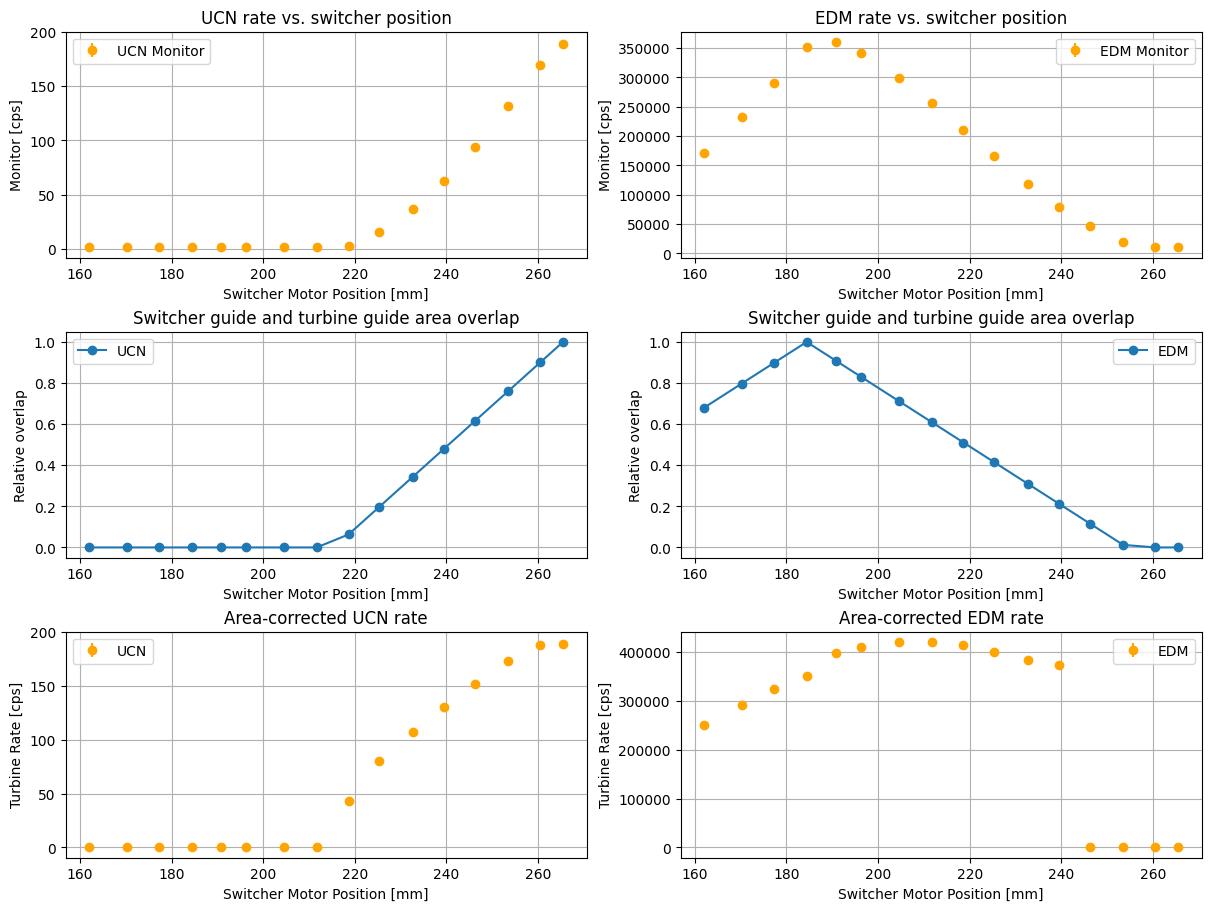

In [14]:
# first measurement
sw_height_001 = motorpos_to_mm(sw_pos_001)

UCN_rate_001, UCN_rate_err_001 = get_UCN_mon((8311,8326))
UCN_overlap_001 = calc_areaoverlap(sw_height_001, UCN_mm, UCN_height)
UCN_ac_rate_001, UCN_ac_err_001  = calc_areacorr_rate(UCN_rate_001, UCN_rate_err_001, UCN_overlap_001)

EDM_rate_001, EDM_rate_err_001 = get_EDM_mon((6,21),"090626")
EDM_overlap_001 = calc_areaoverlap(sw_height_001, EDM_mm, EDM_height)
EDM_ac_rate_001, EDM_ac_err_001 = calc_areacorr_rate(EDM_rate_001, EDM_rate_err_001, EDM_overlap_001, threshold = 0.15)

plot_all(sw_pos_001, sw_height_001, UCN_rate_001, UCN_rate_err_001, UCN_overlap_001, UCN_ac_rate_001, UCN_ac_err_001,
         sw_pos_001, sw_height_001, EDM_rate_001, EDM_rate_err_001, EDM_overlap_001, EDM_ac_rate_001, EDM_ac_err_001,
         mm = True)

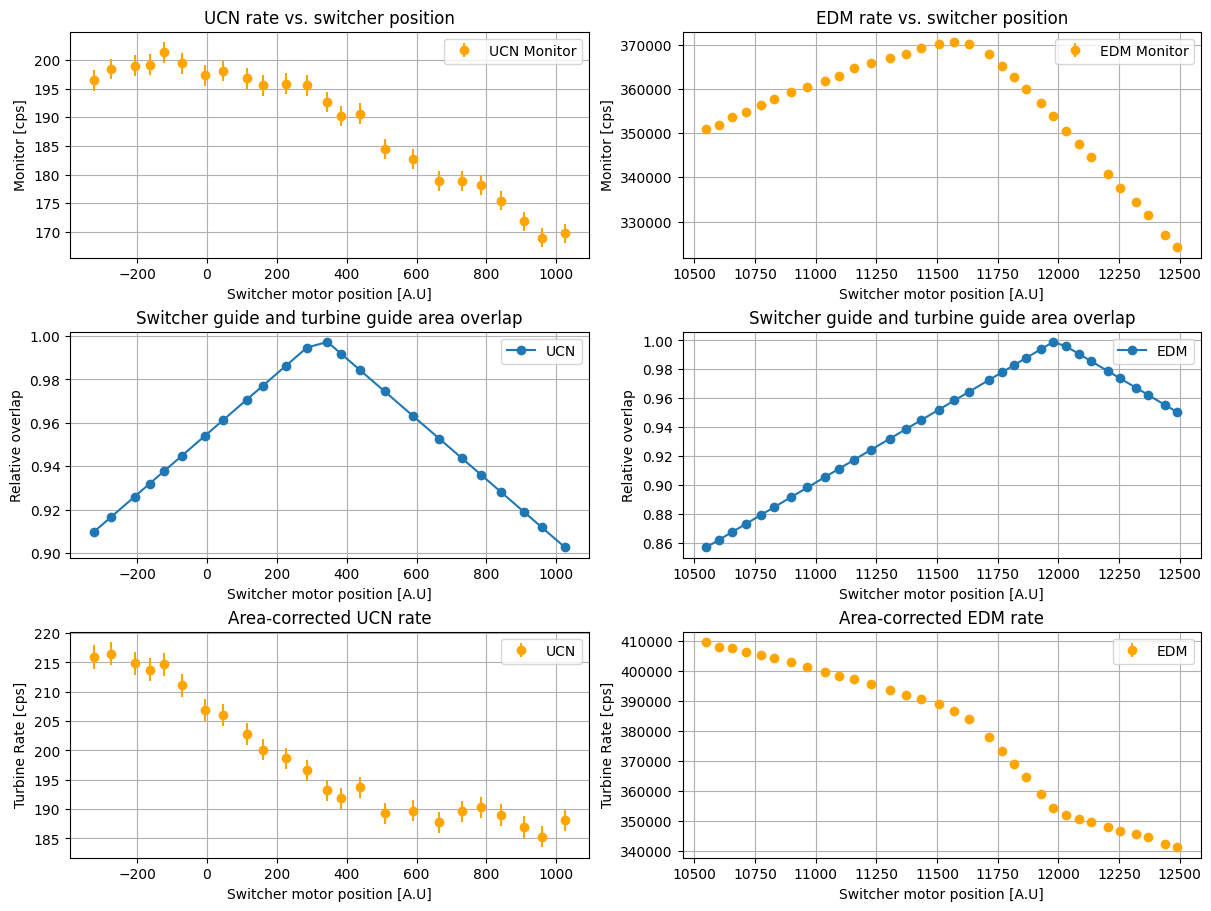

In [15]:
# second and third measurement
sw_height_002 = motorpos_to_mm(sw_pos_002)
UCN_rate_002, UCN_rate_err_002 = get_UCN_mon((8327,8350))
UCN_overlap_002 = calc_areaoverlap(sw_height_002, UCN_mm, UCN_height)
UCN_ac_rate_002, UCN_ac_err_002 = calc_areacorr_rate(UCN_rate_002, UCN_rate_err_002, UCN_overlap_002)

sw_height_003_2 = motorpos_to_mm(sw_pos_003_2)
EDM_rate_003_2, EDM_rate_err_003_2 = get_EDM_mon((2,43),"150626", exclude=(35,36, 37, 38, 39, 40, 41, 42, 43))
EDM_overlap_003_2 = calc_areaoverlap(sw_height_003_2, EDM_mm, EDM_height)
EDM_ac_rate_003_2, EDM_ac_err_003_2 = calc_areacorr_rate(EDM_rate_003_2, EDM_rate_err_003_2, EDM_overlap_003_2)

plot_all(sw_pos_002, sw_height_002, UCN_rate_002, UCN_rate_err_002, UCN_overlap_002, UCN_ac_rate_002, UCN_ac_err_002,
         sw_pos_003_2, sw_height_003_2, EDM_rate_003_2, EDM_rate_err_003_2, EDM_overlap_003_2, EDM_ac_rate_003_2,
         EDM_ac_err_003_2, 
         mm = False)

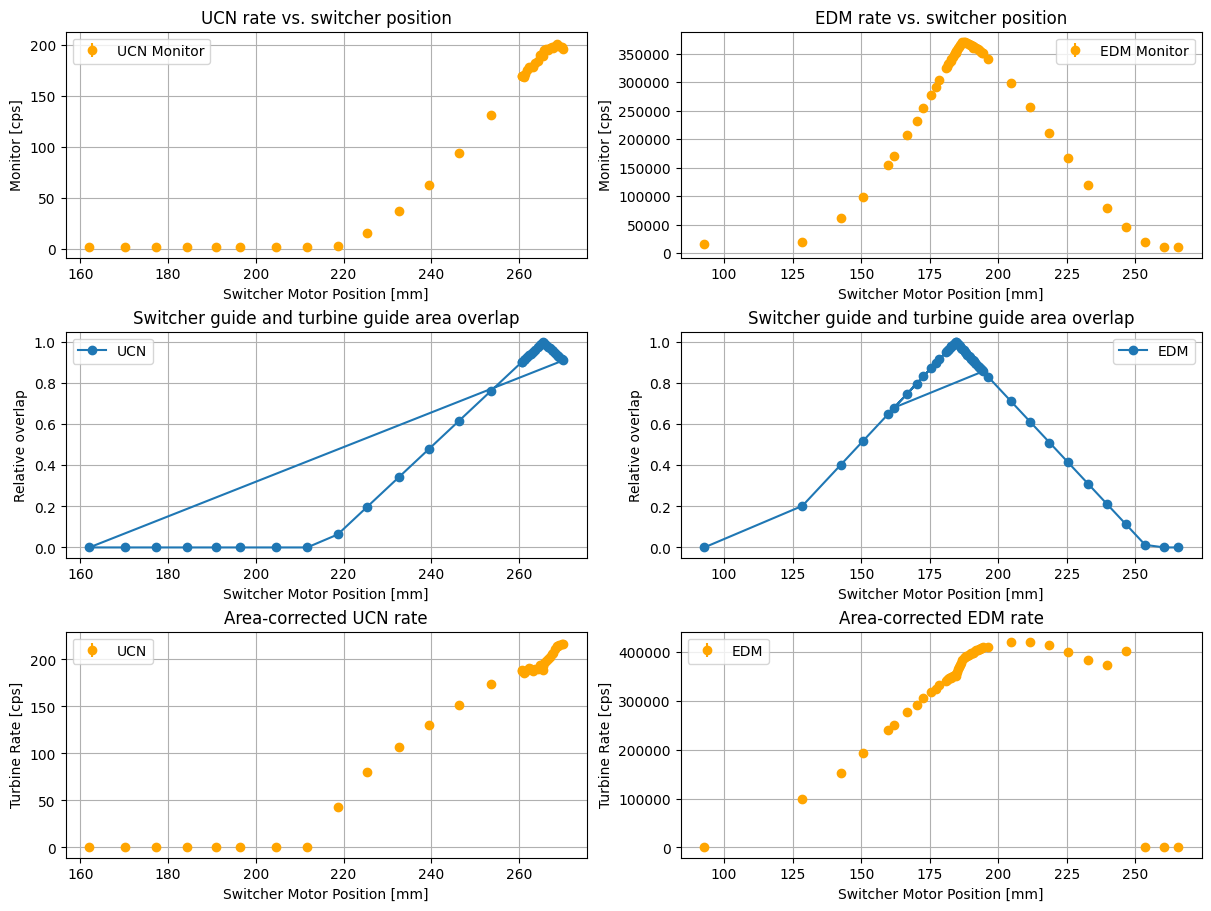

In [16]:
# combine all datapoints
sw_pos_004 = sw_pos_001 + sw_pos_002
sw_height_004 = motorpos_to_mm(sw_pos_004)
UCN_rate_004 = np.concatenate([UCN_rate_001, UCN_rate_002])
UCN_rate_err_004 = np.concatenate([UCN_rate_err_001, UCN_rate_err_002])
UCN_overlap_004 = calc_areaoverlap(sw_height_004, UCN_mm, UCN_height)
UCN_ac_rate_004, UCN_ac_err_004 = calc_areacorr_rate(UCN_rate_004, UCN_rate_err_004, UCN_overlap_004)

sw_pos_005 = sw_pos_001 + sw_pos_003
sw_height_005 = motorpos_to_mm(sw_pos_005)
EDM_rate_003, EDM_rate_err_003 = get_EDM_mon((2,43),"150626")
EDM_rate_005 = np.concatenate([EDM_rate_001, EDM_rate_003])
EDM_rate_err_005 = np.concatenate([EDM_rate_err_001, EDM_rate_err_003])
EDM_overlap_005 = calc_areaoverlap(sw_height_005, EDM_mm, EDM_height)
EDM_ac_rate_005, EDM_ac_err_005 = calc_areacorr_rate(EDM_rate_005, EDM_rate_err_005, EDM_overlap_005, threshold = 0.1)

plot_all(sw_pos_004, sw_height_004, UCN_rate_004, UCN_rate_err_004, UCN_overlap_004, UCN_ac_rate_004, UCN_ac_err_004,
         sw_pos_005, sw_height_005, EDM_rate_005, EDM_rate_err_005, EDM_overlap_005, EDM_ac_rate_005, EDM_ac_err_005,
         mm = True)

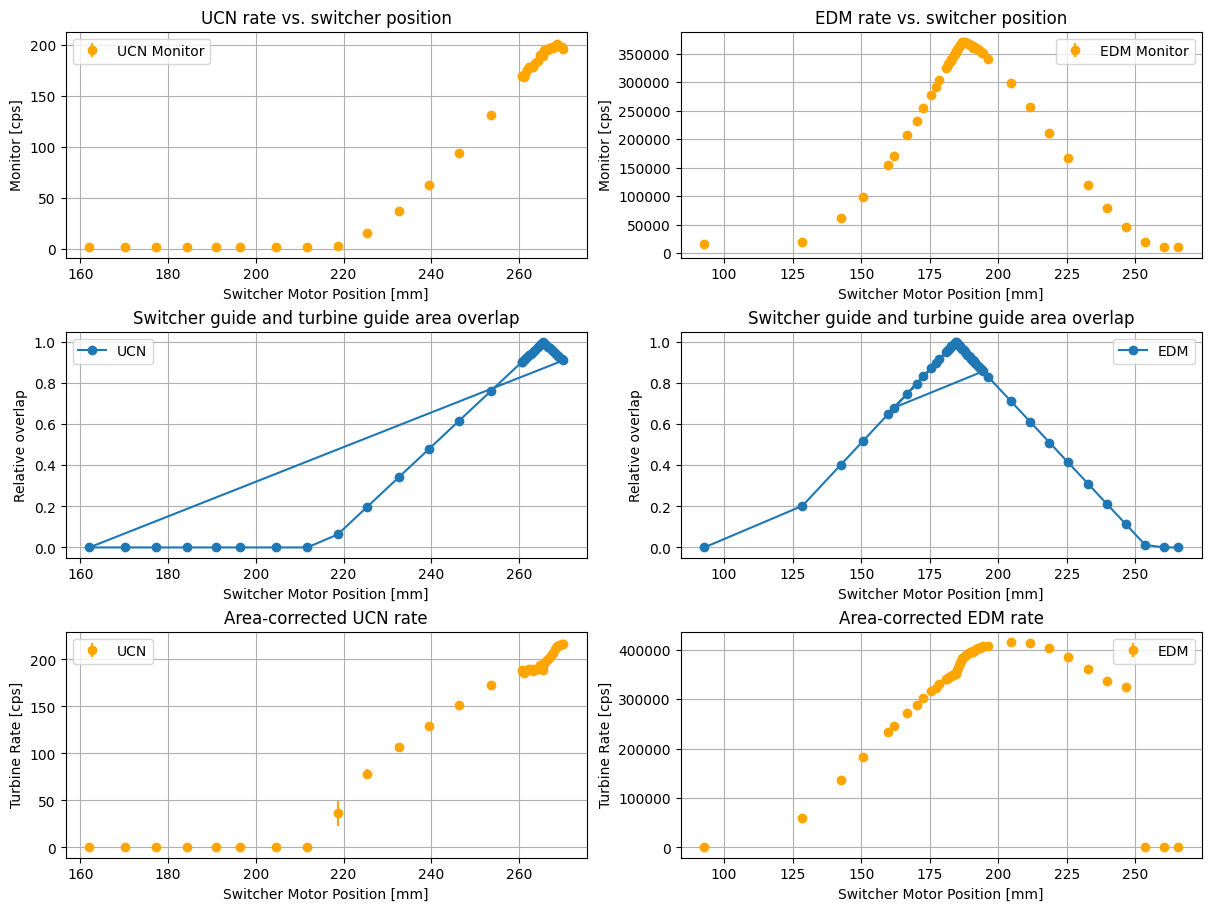

In [17]:
# combine all datapoints
sw_pos_004 = sw_pos_001 + sw_pos_002
sw_height_004 = motorpos_to_mm(sw_pos_004)
UCN_rate_004 = np.concatenate([UCN_rate_001, UCN_rate_002])
UCN_rate_err_004 = np.concatenate([UCN_rate_err_001, UCN_rate_err_002])
UCN_overlap_004 = calc_areaoverlap(sw_height_004, UCN_mm, UCN_height)
UCN_ac_rate_006, UCN_ac_err_006 = calc_areacorr_rate2(UCN_rate_004, UCN_rate_err_004, UCN_overlap_004, UCN_background_rate)

sw_pos_005 = sw_pos_001 + sw_pos_003
sw_height_005 = motorpos_to_mm(sw_pos_005)
EDM_rate_003, EDM_rate_err_003 = get_EDM_mon((2,43),"150626")
EDM_rate_005 = np.concatenate([EDM_rate_001, EDM_rate_003])
EDM_rate_err_005 = np.concatenate([EDM_rate_err_001, EDM_rate_err_003])
EDM_overlap_005 = calc_areaoverlap(sw_height_005, EDM_mm, EDM_height)
EDM_ac_rate_007, EDM_ac_err_007 = calc_areacorr_rate2(EDM_rate_005, EDM_rate_err_005, EDM_overlap_005, EDM_background_rate, threshold = 0.1)

plot_all(sw_pos_004, sw_height_004, UCN_rate_004, UCN_rate_err_004, UCN_overlap_004, UCN_ac_rate_006, UCN_ac_err_006,
         sw_pos_005, sw_height_005, EDM_rate_005, EDM_rate_err_005, EDM_overlap_005, EDM_ac_rate_007, EDM_ac_err_007,
         mm = True)

In [18]:
def scale_rate(rate, rate_err, value_one):
    if value_one < 0.01:
        print("value_one too small")
    else:
        rate = rate/value_one
        rate_err = rate_err/value_one
    return rate, rate_err

In [19]:
def center_on_zero(value_list, value_zero):
    new_list = []
    for value in value_list:
        new_list.append(value - value_zero)
    return new_list

In [20]:
# plot normalized and zero-centered rates
def plot_normalized(UCN_sw_pos, UCN_rate, UCN_rate_err, UCN_normalization,
    EDM_sw_pos, EDM_rate, EDM_rate_err, EDM_normalization,
    mm = False
):
    y_UCN, yerr_UCN = scale_rate(UCN_rate, UCN_rate_err, UCN_normalization)
    y_EDM, yerr_EDM = scale_rate(EDM_rate, EDM_rate_err, EDM_normalization)

    fig, axs = plt.subplots(1,1,figsize=(12,9))#, constrained_layout=True)
    if mm == True:
        x_UCN = center_on_zero(UCN_sw_pos, UCN_mm)
        x_EDM = center_on_zero(EDM_sw_pos, EDM_mm)
        axs.set_xlabel("Delta Switcher Position [mm]")
        #axs[1].set_xlabel("Switcher Position relative to EDM position [mm]")
    else:
        x_UCN = center_on_zero(UCN_sw_pos, UCN_pos)
        x_EDM = center_on_zero(EDM_sw_pos, EDM_pos)
        axs.set_xlabel("Delta Motor Position [A.U.]")
        #axs[1].set_xlabel("Motor Position relative to EDM position [A.U.]")     

    axs.errorbar(x_UCN, y_UCN, yerr=yerr_UCN, fmt='o', label='UCN', color='orange')
    axs.errorbar(x_EDM, y_EDM, yerr=yerr_EDM, fmt='o', label='EDM', color='blue', alpha=0.3)
    axs.set_title("Normalized rate centered on switcher position")
    axs.set_ylabel("Relative rate")
    axs.grid(True)
    axs.legend()

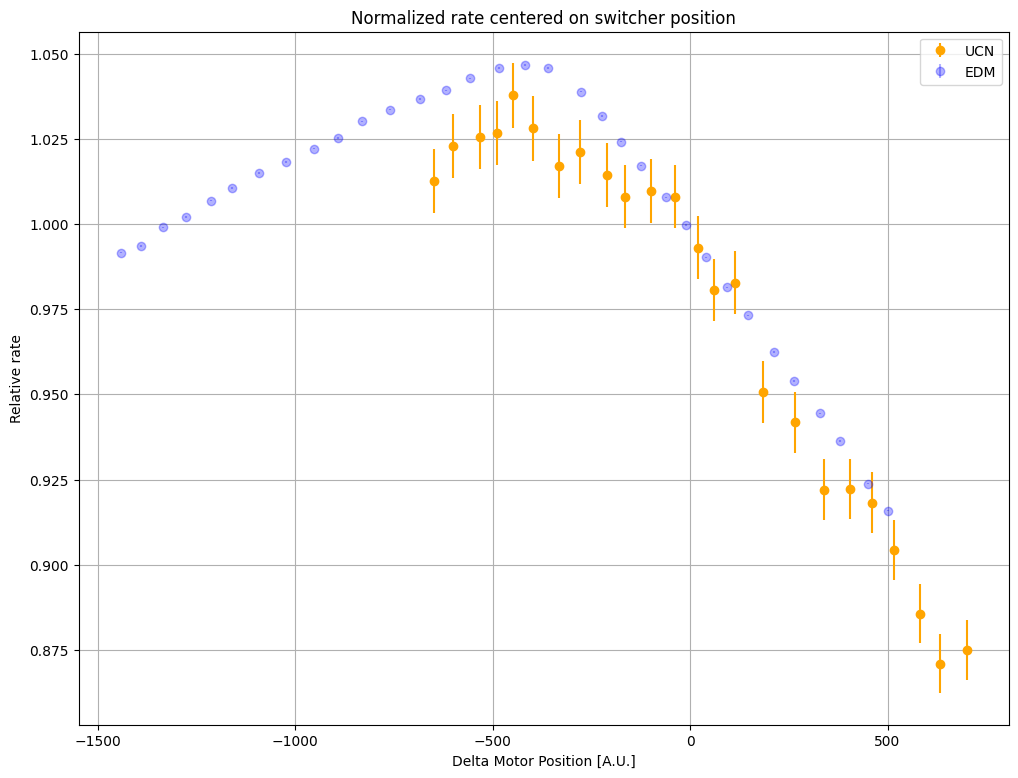

In [21]:
plot_normalized(sw_pos_002, UCN_rate_002, UCN_rate_err_002, UCN_norm_rate,
    sw_pos_003_2, EDM_rate_003_2, EDM_rate_err_003_2, EDM_norm_rate)

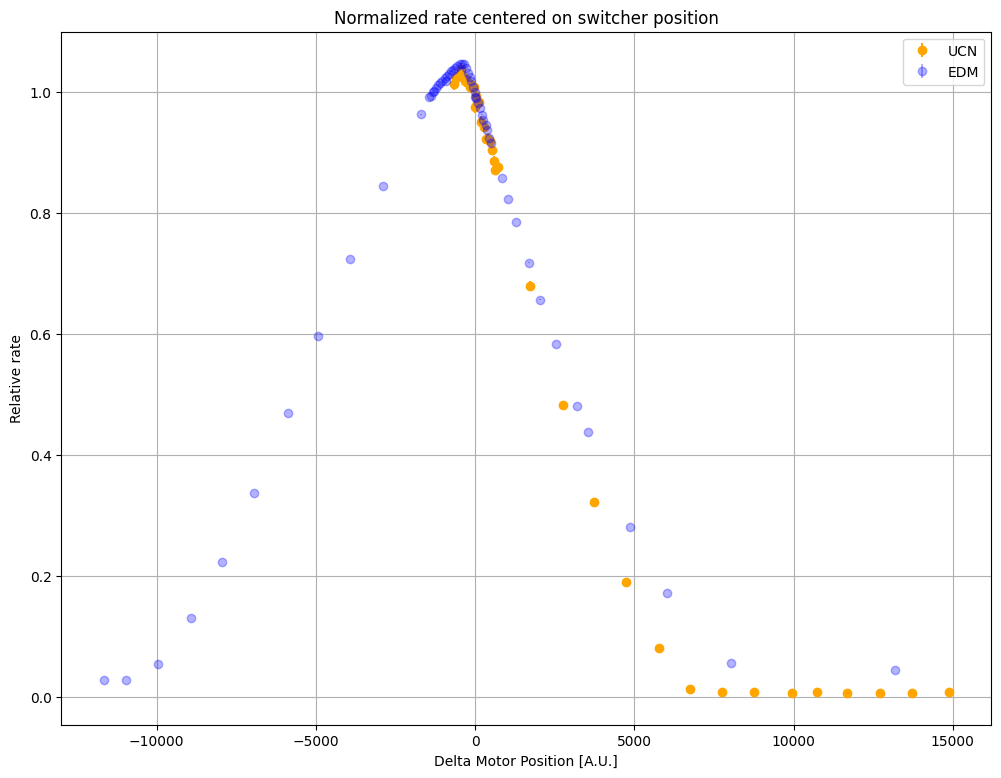

In [22]:
plot_normalized(sw_pos_004, UCN_rate_004, UCN_rate_err_004, UCN_norm_rate,
    sw_pos_005, EDM_rate_005, EDM_rate_err_005, EDM_norm_rate)

In [23]:
def get_common_area(a, b, delta_x, delta_y, r):
    # calculates the area of the rectangle that is also inside the circle
    # a*b = area of rectangle, a is length in x, b is length in y
    # delta_x is distance from origin in x dimension, delta_y in y dim
    # r is radius of circle
    def integrate_sinarccos(lower_limit, upper_limit, r):
        # integrate f(x)= sin(arccos(x/r) form lower_limit to upper limit
        def antiderivative_sinarccos(x,r):
            if r < 0.0001:
                print("Error: r is too small")
                return float('nan')
            x_r = x/r
            return 0.5*r*np.arcsin(x_r) + 0.5*x*math.sqrt(1-x_r**2)
            
        if lower_limit > upper_limit:
            print("Error: lower_limit > upper_limit")
            return 0.0
        # Int f(x) = F(b) - F(a)
        return antiderivative_sinarccos(upper_limit,r) - antiderivative_sinarccos(lower_limit,r)

    if a < 0.0 or b < 0.0 or delta_x < 0.0 or delta_y < 0.0 or r < 0.0001:
        print("Error: Input variables too small")

    if (delta_x**2 + delta_y**2) >= r**2:
        # rectangle not inside circleUCN_ac_err_006
        return 0.0
    if ((a+delta_x)**2 + (b+delta_y)**2) <= r**2:
        # rectangle is completely inside circle
        return a*b
    # rectangle is partly inside circle -> calculate

    del_x = a # if b+delta_y >= r
    if (b + delta_y) < r:
        del_x = delta_x + a - math.sqrt(r**2 - (b+delta_y)**2)
    if del_x > a:
        # see point 10]
        del_x = a

    lower_boundary = delta_x + a - del_x
    upper_boundary = delta_x + a # if a+delta_x <= r
    if (delta_x + a) > r:
        upper_boundary = r

    A1 = r*integrate_sinarccos(lower_boundary, upper_boundary, r) + (b+delta_y)*(a-del_x)
    A2 = 0.0
    #print(r*integrate_sinarccos(lower_boundary, upper_boundary, r))
    #print((b+delta_y)*(a-del_x))
    #print(a*delta_y)
    #print(f"del_x = {del_x}")
    #print(f"A2 = {A2}")
    #print(f"A1 Int = {r*integrate_sinarccos(lower_boundary, upper_boundary, r)}, A1 prod = {(b+delta_y)*(a-del_x)}") 
          
    if delta_y > 0.0:
        b = delta_y
        delta_y = 0.0
        if (delta_x**2 + delta_y**2) >= r**2:
            # Second rectangle not inside circle
            A2 = 0.0
        elif ((a+delta_x)**2 + (b+delta_y)**2) <= r**2:
            # Second rectangle is completely inside circle
            A2 = a*b
        else:
            # Second rectangle is partly inside circle -> calculate
            del_x = a # if b+delta_y >= r; impossible in second rectangle
            if (b + delta_y) < r:
                del_x2 = delta_x + a - math.sqrt(r**2 - (b+delta_y)**2)
        
            lower_boundary2 = delta_x + a - del_x2
            upper_boundary2 = delta_x + a # if a+delta_x <= r
            if (delta_x + a) > r:
                upper_boundary2 = r
            A2 = r*integrate_sinarccos(lower_boundary2, upper_boundary2, r) + (b+delta_y)*(a-del_x2)
            #print(f"A2 Int = {r*integrate_sinarccos(lower_boundary2, upper_boundary2, r)}, A2 prod = {(b+delta_y)*(a-del_x2)}") 

    #print(f"lower_boundary of A1 = {lower_boundary}, upper_boundary of A1 = {upper_boundary}")
    #print(f"lower_boundary of A2 = {lower_boundary2}, upper_boundary of A2 = {upper_boundary2}")
    #print(A1)
    #print(A2)
    return A1-A2
#print(get_common_area(7.0, 7.0, 48.0, 62.0, 80.0))

def get_turbine_overlap(height, a, b, delta_x):
    # https://www.geogebra.org/calculator/p5qahun7
    R1 = 852.0 # inner radius
    R2 = 1012.0 # outer radius

    if np.isscalar(height):
        A = get_common_area(a, b, delta_x, height, R2) - get_common_area(a, b, delta_x, height, R1)
        return A/(a*b)
    A = []
    for h in height:
        A.append((get_common_area(a, b, delta_x, h, R2) - get_common_area(a, b, delta_x, h, R1))/(a*b))
    return A

#print(get_turbine_overlap(567.0, EDM_width, EDM_height))

def convert_pos_to_turbineheight(sw_pos, is_EDM=True):
    th = []
    # center and peripheral position of beam guides to be taken from drawing
    th_EDM_center = 710.65
    th_EDM_peri = 629.65
    th_UCN_center = 722.85
    th_UCN_peri = 803.85
    if is_EDM == True:
        step_mm = (th_EDM_center-th_EDM_peri)/(EDM_pos-UCN_pos)
        for pos in sw_pos:
            th.append(th_EDM_peri + step_mm*(pos-UCN_pos))
    else:
        step_mm = (th_UCN_peri-th_UCN_center)/(EDM_pos-UCN_pos)
        for pos in sw_pos:
            th.append(th_UCN_center + step_mm*(pos-UCN_pos))
    return np.array(th)

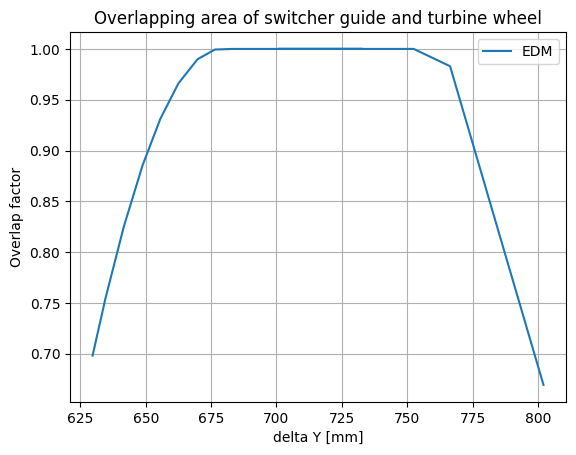

In [24]:
sw_tb_005 = convert_pos_to_turbineheight(sw_pos_005)
EDM_turbine_ol_005 = get_turbine_overlap(sw_tb_005, EDM_width, EDM_height, EDM_delta_x)
plt.plot(sw_tb_005, EDM_turbine_ol_005, label="EDM")
plt.xlabel("delta Y [mm]")
plt.ylabel("Overlap factor")
plt.title("Overlapping area of switcher guide and turbine wheel")
plt.legend()
plt.grid(True)

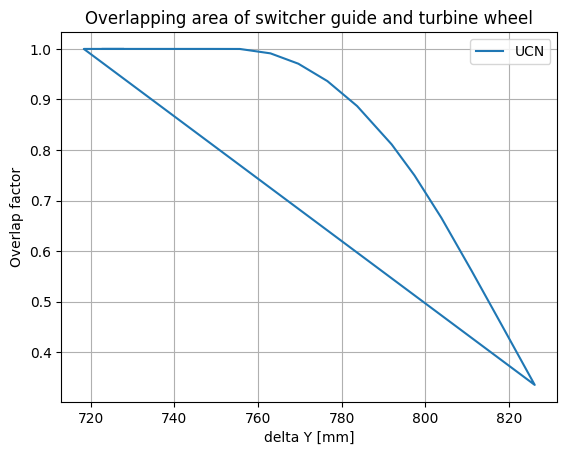

In [25]:
sw_tb_004 = convert_pos_to_turbineheight(sw_pos_004, is_EDM=False)
UCN_turbine_ol_004 = get_turbine_overlap(sw_tb_004, UCN_width, UCN_height, UCN_delta_x)
plt.plot(sw_tb_004, UCN_turbine_ol_004, label="UCN")
plt.xlabel("delta Y [mm]")
plt.ylabel("Overlap factor")
plt.title("Overlapping area of switcher guide and turbine wheel")
plt.legend()
plt.grid(True)

In [26]:
def calc_turbareacorr_rate(mon_corr, std_mon_corr, turbine_overlap, threshold = 0.01):
    turbine_rate = np.zeros(len(turbine_overlap))
    turbine_rate_err = np.zeros(len(turbine_overlap))
    for i in range(len(mon_corr)):
        if turbine_overlap[i] > threshold:
            turbine_rate[i] = mon_corr[i]/turbine_overlap[i]
            turbine_rate_err[i] = std_mon_corr[i]/turbine_overlap[i]
    return turbine_rate, turbine_rate_err

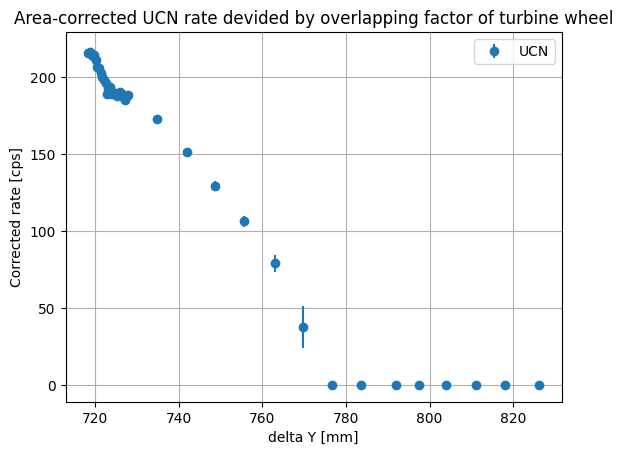

In [27]:
UCN_tb_rate_004, UCN_tb_err_004 = calc_turbareacorr_rate(UCN_ac_rate_006, UCN_ac_err_006, UCN_turbine_ol_004)
plt.errorbar(sw_tb_004, UCN_tb_rate_004, yerr=UCN_tb_err_004, fmt='o', label="UCN")
plt.xlabel("delta Y [mm]")
plt.ylabel("Corrected rate [cps]")
plt.title("Area-corrected UCN rate devided by overlapping factor of turbine wheel")
plt.legend()
plt.grid(True)

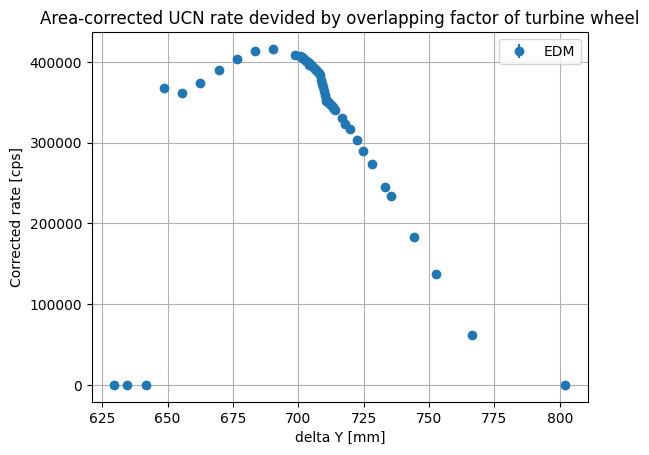

In [28]:
EDM_tb_rate_005, EDM_tb_err_005 = calc_turbareacorr_rate(EDM_ac_rate_007, EDM_ac_err_007, EDM_turbine_ol_005)
plt.errorbar(sw_tb_005, EDM_tb_rate_005, yerr=EDM_tb_err_005, fmt='o', label="EDM")
plt.xlabel("delta Y [mm]")
plt.ylabel("Corrected rate [cps]")
plt.title("Area-corrected UCN rate devided by overlapping factor of turbine wheel")
plt.legend()
plt.grid(True)

In [29]:
def plot_all2(
    UCN_sw_pos, UCN_sw_height, UCN_tb_height, UCN_rate, UCN_rate_err, UCN_guide_overlap, 
    UCN_ac_rate, UCN_ac_err, UCN_tb_overlap, UCN_tb_rate, UCN_tb_err,
    EDM_sw_pos, EDM_sw_height, EDM_tb_height, EDM_rate, EDM_rate_err, EDM_guide_overlap, 
    EDM_ac_rate, EDM_ac_err, EDM_tb_overlap, EDM_tb_rate, EDM_tb_err,
    mode = "pos"
):
    fig, axs = plt.subplots(5,2,figsize=(11,9), constrained_layout=True)
    if mode == "mm":
        x_UCN = UCN_sw_height
        x_EDM = EDM_sw_height
        axs[0, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[0, 1].set_xlabel("Switcher Motor Position [mm]")
        axs[1, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[1, 1].set_xlabel("Switcher Motor Position [mm]")
        axs[2, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[2, 1].set_xlabel("Switcher Motor Position [mm]")
        axs[3, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[3, 1].set_xlabel("Switcher Motor Position [mm]")
        axs[4, 0].set_xlabel("Switcher Motor Position [mm]")
        axs[4, 1].set_xlabel("Switcher Motor Position [mm]")
    elif mode == "pos":
        x_UCN = UCN_sw_pos
        x_EDM = EDM_sw_pos
        axs[0, 0].set_xlabel("Switcher motor position [A.U]")
        axs[0, 1].set_xlabel("Switcher motor position [A.U]")
        axs[1, 0].set_xlabel("Switcher motor position [A.U]")
        axs[1, 1].set_xlabel("Switcher motor position [A.U]")
        axs[2, 0].set_xlabel("Switcher motor position [A.U]")
        axs[2, 1].set_xlabel("Switcher motor position [A.U]")
        axs[3, 0].set_xlabel("Switcher motor position [A.U]")
        axs[3, 1].set_xlabel("Switcher motor position [A.U]")
        axs[4, 0].set_xlabel("Switcher motor position [A.U]")
        axs[4, 1].set_xlabel("Switcher motor position [A.U]")
    elif mode == "tb":
        x_UCN = UCN_tb_height
        x_EDM = EDM_tb_height
        axs[0, 0].set_xlabel("delta Y [mm]")
        axs[0, 1].set_xlabel("delta Y [mm]")
        axs[1, 0].set_xlabel("delta Y [mm]")
        axs[1, 1].set_xlabel("delta Y [mm]")
        axs[2, 0].set_xlabel("delta Y [mm]")
        axs[2, 1].set_xlabel("delta Y [mm]")
        axs[3, 0].set_xlabel("delta Y [mm]")
        axs[3, 1].set_xlabel("delta Y [mm]")
        axs[4, 0].set_xlabel("delta Y [mm]")
        axs[4, 1].set_xlabel("delta Y [mm]")
    else:
        print(f"Error: mode {mode} not defined")
        return
    
    # measured rate
    axs[0, 0].errorbar(x_UCN, UCN_rate, yerr=UCN_rate_err, fmt='o', label='UCN Monitor', color='orange')
    axs[0, 0].set_title("UCN rate vs. switcher position")
    axs[0, 0].set_ylabel("Monitor [cps]")
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    axs[0, 1].errorbar(x_EDM, EDM_rate, yerr=EDM_rate_err, fmt='o', label='EDM Monitor', color='orange')
    axs[0, 1].set_title("EDM rate vs. switcher position")
    axs[0, 1].set_ylabel("Monitor [cps]")
    axs[0, 1].grid(True)
    axs[0, 1].legend()

    # guide overlap
    axs[1, 0].scatter(x_UCN, UCN_guide_overlap, marker = "o", label='UCN')
    axs[1, 0].legend()
    axs[1, 0].set_ylabel("Relative overlap")
    axs[1, 0].set_title("Switcher guide and turbine guide area overlap")
    axs[1, 0].grid(True)

    axs[1, 1].scatter(x_EDM, EDM_guide_overlap, marker = "o", label='EDM')
    axs[1, 1].legend()
    axs[1, 1].set_ylabel("Relative overlap")
    axs[1, 1].set_title("Switcher guide and turbine guide area overlap")
    axs[1, 1].grid(True)

    # ac_rate    
    axs[2, 0].errorbar(x_UCN, UCN_ac_rate, yerr=UCN_ac_err, fmt = "o", label='UCN', color='orange')
    axs[2, 0].legend()
    axs[2, 0].set_ylabel("Turbine Rate [cps]")
    axs[2, 0].set_title("Area-corrected UCN rate")
    axs[2, 0].grid(True)

    axs[2, 1].errorbar(x_EDM, EDM_ac_rate, yerr=EDM_ac_err, fmt = "o", label='EDM', color='orange')
    axs[2, 1].legend()
    axs[2, 1].set_ylabel("Turbine Rate [cps]")
    axs[2, 1].set_title("Area-corrected EDM rate")
    axs[2, 1].grid(True)

    # turbine overlap
    axs[3, 0].scatter(x_UCN, UCN_tb_overlap, marker = "o", label='UCN')
    axs[3, 0].legend()
    axs[3, 0].set_ylabel("Relative overlap")
    axs[3, 0].set_title("Switcher guide and turbine wheel area overlap")
    axs[3, 0].grid(True)

    axs[3, 1].scatter(x_EDM, EDM_tb_overlap, marker = "o", label='EDM')
    axs[3, 1].legend()
    axs[3, 1].set_ylabel("Relative overlap")
    axs[3, 1].set_title("Switcher guide and turbine wheel area overlap")
    axs[3, 1].grid(True)

    # tb_rate    
    axs[4, 0].errorbar(x_UCN, UCN_tb_rate, yerr=UCN_tb_err, fmt = "o", label='UCN', color='orange')
    axs[4, 0].legend()
    axs[4, 0].set_ylabel("Turbine Rate [cps]")
    axs[4, 0].set_title("Area-corrected EDM rate devided by turbine wheel overlap")
    axs[4, 0].grid(True)

    axs[4, 1].errorbar(x_EDM, EDM_tb_rate, yerr=EDM_tb_err, fmt = "o", label='EDM', color='orange')
    axs[4, 1].legend()
    axs[4, 1].set_ylabel("Turbine Rate [cps]")
    axs[4, 1].set_title("Area-corrected EDM rate devided by turbine wheel overlap")
    axs[4, 1].grid(True)

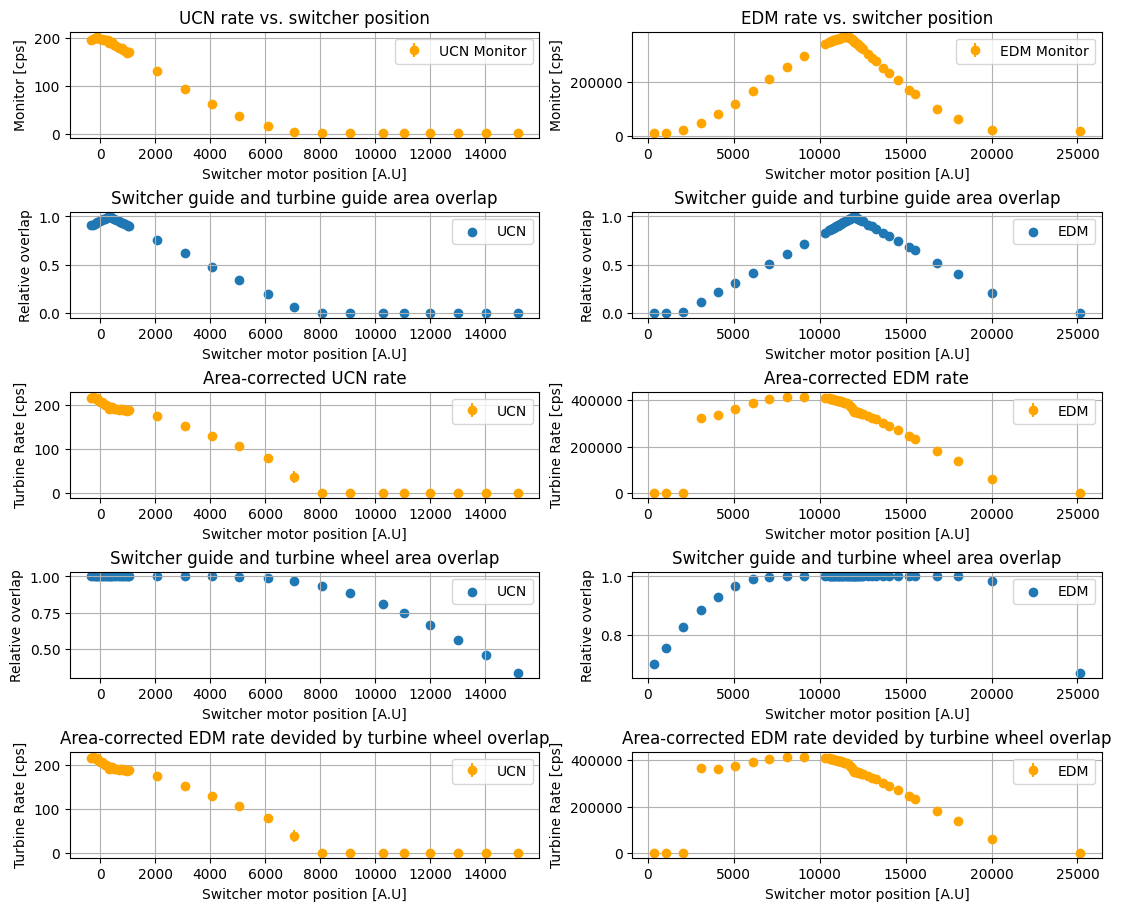

In [30]:
plot_all2(sw_pos_004, sw_height_004, sw_tb_004, UCN_rate_004, UCN_rate_err_004, UCN_overlap_004, 
          UCN_ac_rate_006, UCN_ac_err_006, UCN_turbine_ol_004, UCN_tb_rate_004, UCN_tb_err_004,
          sw_pos_005, sw_height_005, sw_tb_005, EDM_rate_005, EDM_rate_err_005, EDM_overlap_005, 
          EDM_ac_rate_007, EDM_ac_err_007, EDM_turbine_ol_005, EDM_tb_rate_005, EDM_tb_err_005,
          mode = "pos")

In [36]:
UCN_dumb = {'Switcher position [A.U]': sw_pos_004,
        'Switcher position [mm]': sw_height_004,
        'delta Y [mm]': sw_tb_004,
        'Rate [counts/s]': UCN_rate_004,
        'Rate error [counts/s]': UCN_rate_err_004,
        'Guides overlap': UCN_overlap_004,
        'Guide-area-corr rate [counts/s]': UCN_ac_rate_006,
        'Guide-area-corr rate error [counts/s]': UCN_ac_err_006,
        'Turbine overlap': UCN_turbine_ol_004,
        'Turbine-area-corr rate [counts/s]': UCN_tb_rate_004,
        'Turbine-area-corr rate err [counts/s]': UCN_tb_err_004}

EDM_dumb = {'Switcher position [A.U]': sw_pos_005,
        'Switcher position [mm]': sw_height_005,
        'delta Y [mm]': sw_tb_005,
        'Rate [counts/s]': EDM_rate_005,
        'Rate error [counts/s]': EDM_rate_err_005,
        'Guides overlap': EDM_overlap_005,
        'Guide-area-corr rate [counts/s]': EDM_ac_rate_007,
        'Guide-area-corr rate error [counts/s]': EDM_ac_err_007,
        'Turbine overlap': EDM_turbine_ol_005,
        'Turbine-area-corr rate [counts/s]': EDM_tb_rate_005,
        'Turbine-area-corr rate err [counts/s]': EDM_tb_err_005}

UCN_df = pd.DataFrame(UCN_dumb)
#print(UCN_df)
UCN_df.to_csv("/home/fiscfeli/MyData/byProposal/exp_3-14-458_262_pf2ucn/processed/felixf/UCN_dumb.csv", header=True, index=False)
EDM_df = pd.DataFrame(EDM_dumb)
EDM_df.to_csv("/home/fiscfeli/MyData/byProposal/exp_3-14-458_262_pf2ucn/processed/felixf/EDM_dumb.csv", header=True, index=False)
